# 05. Beta-VAE 실험

β 값을 바꿔가며 재구성 품질 vs 잠재 공간 분리도(disentanglement) 트레이드오프를 비교합니다.

| β | 특성 |
|---|------|
| 1.0 | 표준 VAE — 재구성 품질 우선 |
| 2–4 | 균형 |
| 8–16 | 잠재 공간 분리 강화, 재구성 품질 저하 |

## 1. 환경 설정

In [1]:
import os, time, random, json
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image

# CWD 고정
_root = Path(os.path.abspath(''))
for _p in [_root] + list(_root.parents):
    if (_p / 'dataset' / 'processed').exists():
        os.chdir(_p); break
print(f'CWD: {Path.cwd()}')

if torch.backends.mps.is_available():
    DEVICE = torch.device('mps')
elif torch.cuda.is_available():
    DEVICE = torch.device('cuda')
else:
    DEVICE = torch.device('cpu')
print(f'Device: {DEVICE}')

CWD: /Users/gomuseo/Desktop/Python/vae_test
Device: mps


## 2. 실험 설정

In [2]:
CFG = dict(
    processed_root = Path('dataset/processed'),
    categories     = ['body'],
    img_size       = 64,
    channels       = 4,
    val_ratio      = 0.02,

    latent_dim     = 128,
    base_channels  = 32,

    epochs         = 50,
    batch_size     = 128,
    lr             = 0.01,
    num_workers    = 0,
    seed           = 42,

    # 실험할 β 값 목록 — 원하는 값으로 자유롭게 수정
    beta_list      = [0.5, 1.0, 2.0, 4.0],

    save_dir       = Path('checkpoints_beta'),
)
CFG['save_dir'].mkdir(exist_ok=True)

torch.manual_seed(CFG['seed'])
np.random.seed(CFG['seed'])
random.seed(CFG['seed'])
print(f'실험 β 목록: {CFG["beta_list"]}')

실험 β 목록: [0.5, 1.0, 2.0, 4.0]


## 3. 데이터셋

In [3]:
class SpriteDataset(Dataset):
    def __init__(self, paths):
        self.paths = paths
        self.t     = transforms.ToTensor()
    def __len__(self): return len(self.paths)
    def __getitem__(self, i):
        return self.t(Image.open(self.paths[i]).convert('RGBA'))

def collect_paths(root, categories):
    paths = []
    for cat in categories:
        paths += list((root / cat).glob('*.png'))
    return [str(p) for p in paths]

all_paths = collect_paths(CFG['processed_root'], CFG['categories'])
random.shuffle(all_paths)
n_val     = int(len(all_paths) * CFG['val_ratio'])
train_paths, val_paths = all_paths[n_val:], all_paths[:n_val]

train_loader = DataLoader(SpriteDataset(train_paths), CFG['batch_size'],
                          shuffle=True,  num_workers=CFG['num_workers'], drop_last=True)
val_loader   = DataLoader(SpriteDataset(val_paths),   CFG['batch_size'],
                          shuffle=False, num_workers=CFG['num_workers'], drop_last=False)

print(f'학습: {len(train_paths):,}장  검증: {len(val_paths):,}장')
print(f'학습 배치 수: {len(train_loader)}')

학습: 4,454장  검증: 90장
학습 배치 수: 34


## 4. 모델 & 손실 함수

In [4]:
class Encoder(nn.Module):
    def __init__(self, channels=4, base_ch=32, latent_dim=128):
        super().__init__()
        layers, in_ch, ch = [], channels, base_ch
        for _ in range(4):
            layers += [nn.Conv2d(in_ch, ch, 4, stride=2, padding=1),
                       nn.BatchNorm2d(ch, momentum=0.1),
                       nn.LeakyReLU(0.2)]
            in_ch = ch; ch *= 2
        self.conv     = nn.Sequential(*layers)
        self.flat_dim = (base_ch * 8) * 4 * 4
        self.fc_mu    = nn.Linear(self.flat_dim, latent_dim)
        self.fc_lv    = nn.Linear(self.flat_dim, latent_dim)

    def forward(self, x):
        h = self.conv(x).flatten(1)
        return self.fc_mu(h), self.fc_lv(h)


class Decoder(nn.Module):
    def __init__(self, channels=4, base_ch=32, latent_dim=128):
        super().__init__()
        self.start_ch = base_ch * 8
        self.fc       = nn.Linear(latent_dim, self.start_ch * 4 * 4)
        layers, in_ch = [], self.start_ch
        for i, out_ch in enumerate([base_ch*4, base_ch*2, base_ch, channels]):
            layers.append(nn.ConvTranspose2d(in_ch, out_ch, 4, stride=2, padding=1))
            if i < 3:
                layers += [nn.BatchNorm2d(out_ch, momentum=0.1), nn.ReLU()]
            else:
                layers.append(nn.Sigmoid())
            in_ch = out_ch
        self.deconv = nn.Sequential(*layers)

    def forward(self, z):
        return self.deconv(self.fc(z).view(-1, self.start_ch, 4, 4))


class VAE(nn.Module):
    def __init__(self, channels=4, base_ch=32, latent_dim=128):
        super().__init__()
        self.latent_dim = latent_dim
        self.encoder    = Encoder(channels, base_ch, latent_dim)
        self.decoder    = Decoder(channels, base_ch, latent_dim)

    def reparameterize(self, mu, lv):
        return mu + torch.randn_like(mu) * torch.exp(0.5 * lv)

    def forward(self, x):
        mu, lv = self.encoder(x)
        return self.decoder(self.reparameterize(mu, lv)), mu, lv

    @torch.no_grad()
    def sample(self, n, device):
        return self.decoder(torch.randn(n, self.latent_dim, device=device))


def vae_loss(recon, x, mu, log_var, beta):
    batch      = x.size(0)
    recon_loss = F.mse_loss(recon, x, reduction='sum') / batch
    kl_loss    = -0.5 * torch.sum(1 + log_var - mu.pow(2) - log_var.exp()) / batch
    return recon_loss + beta * kl_loss, recon_loss, kl_loss


print('모델 / 손실 함수 정의 완료.')

모델 / 손실 함수 정의 완료.


## 5. 학습 — β별 순차 실행

In [6]:
def train_one_beta(beta, cfg, train_loader, val_loader, device):
    model     = VAE(cfg['channels'], cfg['base_channels'], cfg['latent_dim']).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=cfg['lr'])
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=cfg['epochs'], eta_min=1e-5)
    patience  = max(1, cfg['epochs'] // 10)
    save_path = cfg['save_dir'] / f'beta_{beta:.1f}.pt'

    best_val, no_improve = float('inf'), 0
    history = {'recon': [], 'kl': [], 'val_recon': [], 'val_kl': []}

    print(f'\n── β={beta} 학습 시작 (patience={patience}) ──')
    t0 = time.time()

    for ep in range(1, cfg['epochs'] + 1):
        model.train()
        t_rl = t_kl = 0.0
        for x in train_loader:
            x = x.to(device)
            optimizer.zero_grad()
            r, mu, lv = model(x)
            loss, rl, kl = vae_loss(r, x, mu, lv, beta)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            t_rl += rl.item(); t_kl += kl.item()
        n = len(train_loader)
        history['recon'].append(t_rl / n)
        history['kl'].append(t_kl / n)

        model.eval()
        v_rl = v_kl = 0.0
        with torch.no_grad():
            for x in val_loader:
                x = x.to(device)
                r, mu, lv = model(x)
                _, rl, kl = vae_loss(r, x, mu, lv, beta)
                v_rl += rl.item(); v_kl += kl.item()
        vn = max(len(val_loader), 1)
        val_loss = v_rl / vn + beta * (v_kl / vn)
        history['val_recon'].append(v_rl / vn)
        history['val_kl'].append(v_kl / vn)

        scheduler.step()

        if val_loss < best_val:
            best_val = val_loss; no_improve = 0
            torch.save(model.state_dict(), save_path)
            tag = '✓'
        else:
            no_improve += 1; tag = ''

        if ep % 10 == 0 or ep == 1:
            print(f'  ep {ep:3d}  recon={history["recon"][-1]:.2f}  '
                  f'kl={history["kl"][-1]:.2f}  val_recon={history["val_recon"][-1]:.2f}  '
                  f'val_kl={history["val_kl"][-1]:.2f}  {tag}')

        if no_improve >= patience:
            print(f'  Early Stop at ep {ep}')
            break

    elapsed = time.time() - t0
    print(f'  완료 — {elapsed/60:.1f}분  저장: {save_path}')
    return model, history


results = {}  # {beta: {'model': ..., 'history': ...}}

for beta in CFG['beta_list']:
    model, history = train_one_beta(beta, CFG, train_loader, val_loader, DEVICE)
    results[beta] = {'model': model, 'history': history}

print('\n모든 β 학습 완료.')


── β=0.5 학습 시작 (patience=5) ──
  ep   1  recon=1050.17  kl=29710.66  val_recon=816.07  val_kl=2014.15  ✓
  ep  10  recon=119.84  kl=49.47  val_recon=114.98  val_kl=48.72  ✓
  ep  20  recon=66.03  kl=43.23  val_recon=69.38  val_kl=43.15  ✓
  ep  30  recon=46.42  kl=39.08  val_recon=48.98  val_kl=38.08  ✓
  ep  40  recon=36.83  kl=37.01  val_recon=39.69  val_kl=36.65  
  ep  50  recon=33.74  kl=36.49  val_recon=37.40  val_kl=36.29  
  완료 — 2.4분  저장: checkpoints_beta/beta_0.5.pt

── β=1.0 학습 시작 (patience=5) ──
  ep   1  recon=1230.31  kl=608718.01  val_recon=577.21  val_kl=891.53  ✓
  ep  10  recon=127.61  kl=30.96  val_recon=123.21  val_kl=31.54  ✓
  ep  20  recon=74.04  kl=27.54  val_recon=74.09  val_kl=26.45  ✓
  ep  30  recon=52.80  kl=26.54  val_recon=55.02  val_kl=25.96  ✓
  ep  40  recon=43.02  kl=26.25  val_recon=46.16  val_kl=25.92  
  ep  50  recon=39.83  kl=26.08  val_recon=42.46  val_kl=26.03  ✓
  완료 — 2.4분  저장: checkpoints_beta/beta_1.0.pt

── β=2.0 학습 시작 (patience=5) ──
  e

## 6. 학습 곡선 비교

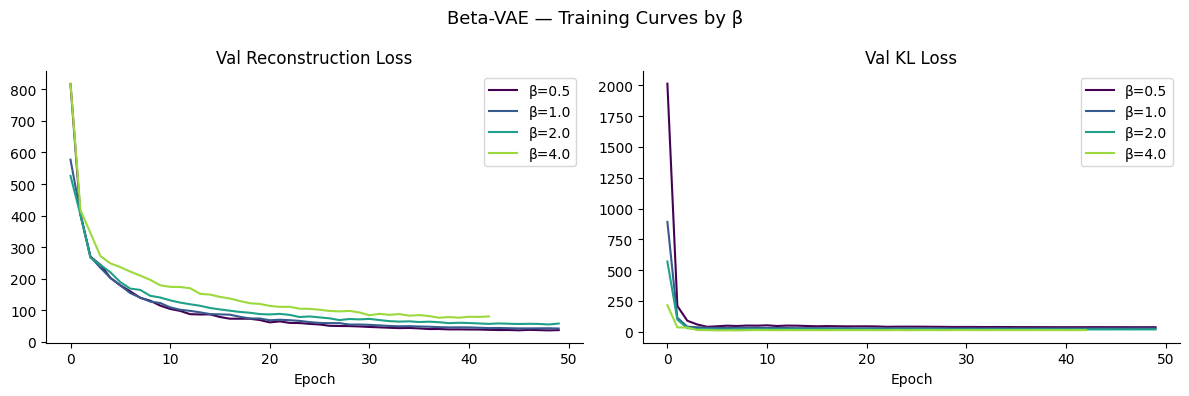

  beta     val_recon      val_kl
----------------------------------
   0.5         37.40       36.29
   1.0         42.46       26.03
   2.0         58.15       18.34
   4.0         80.77       12.62


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
colors = plt.cm.viridis(np.linspace(0, 0.85, len(CFG['beta_list'])))

for (beta, res), color in zip(results.items(), colors):
    h = res['history']
    axes[0].plot(h['val_recon'], label=f'β={beta}', color=color)
    axes[1].plot(h['val_kl'],   label=f'β={beta}', color=color)

axes[0].set_title('Val Reconstruction Loss'); axes[0].set_xlabel('Epoch'); axes[0].legend()
axes[1].set_title('Val KL Loss');             axes[1].set_xlabel('Epoch'); axes[1].legend()
for ax in axes:
    for spine in ['top', 'right']: ax.spines[spine].set_visible(False)
plt.suptitle('Beta-VAE — Training Curves by β', fontsize=13)
plt.tight_layout()
plt.show()

# 최종 수치 표
print(f"{'beta':>6}  {'val_recon':>12}  {'val_kl':>10}")
print('-' * 34)
for beta, res in results.items():
    h = res['history']
    print(f'{beta:>6.1f}  {h["val_recon"][-1]:>12.2f}  {h["val_kl"][-1]:>10.2f}')

## 7. 복원 품질 비교

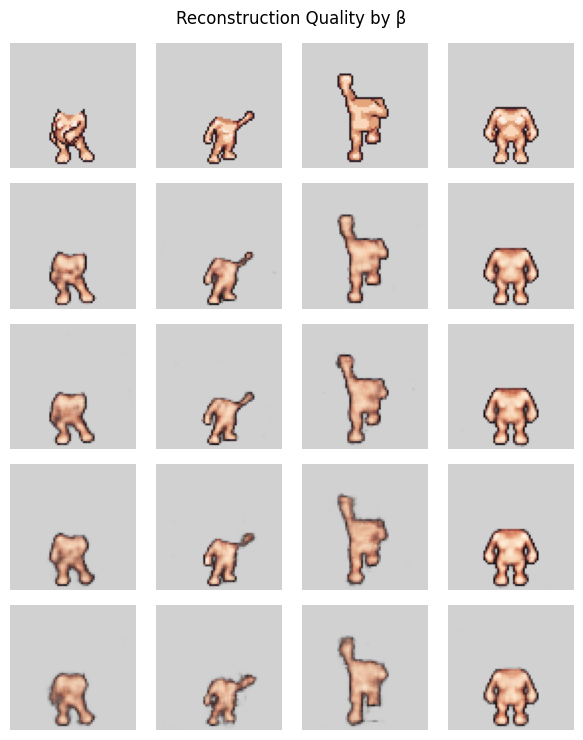

In [15]:
n_show  = 4
bg      = np.array([0.82, 0.82, 0.82])
val_imgs = next(iter(val_loader))[:n_show].to(DEVICE)

n_rows = 1 + len(CFG['beta_list'])   # 원본 1행 + β별 복원 행
fig, axes = plt.subplots(n_rows, n_show, figsize=(n_show * 1.5, n_rows * 1.5))
axes = np.array(axes).reshape(n_rows, n_show)

def composite(tensor):
    arr   = tensor.cpu().permute(1, 2, 0).numpy()
    alpha = arr[:, :, 3:4]
    return np.clip(arr[:, :, :3] * alpha + bg * (1 - alpha), 0, 1)

# 원본
for col in range(n_show):
    axes[0, col].imshow(composite(val_imgs[col]))
    axes[0, col].axis('off')
    axes[0, 0].set_ylabel('Original', fontsize=8)

# β별 복원
for row, (beta, res) in enumerate(results.items(), start=1):
    model = res['model'].eval()
    with torch.no_grad():
        recon, _, _ = model(val_imgs)
    for col in range(n_show):
        axes[row, col].imshow(composite(recon[col]))
        axes[row, col].axis('off')
    axes[row, 0].set_ylabel(f'β={beta}', fontsize=8)

plt.suptitle('Reconstruction Quality by β', fontsize=12)
plt.tight_layout()
plt.show()

## 8. 생성 샘플 비교 (사전 분포에서 샘플링)

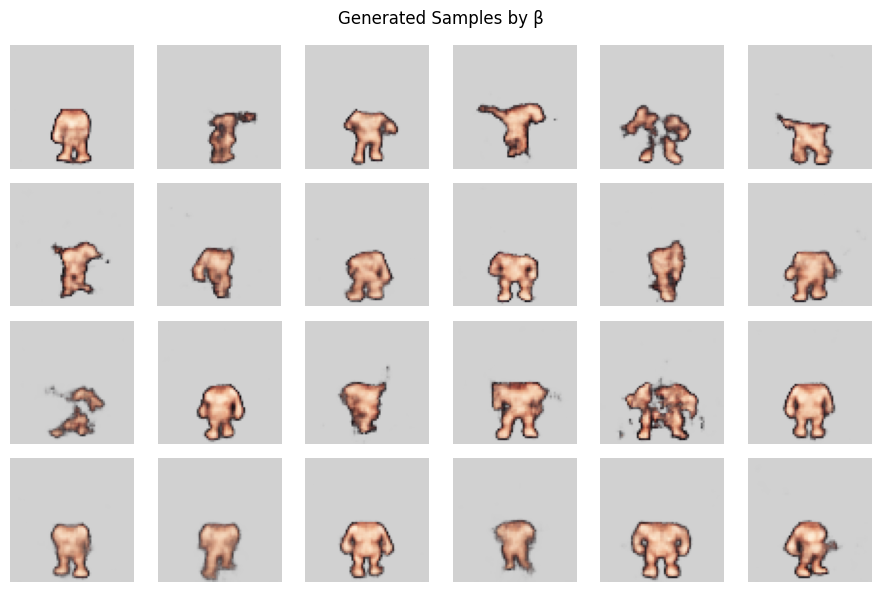

In [11]:
n_samples = 6
torch.manual_seed(0)

n_rows = len(CFG['beta_list'])
fig, axes = plt.subplots(n_rows, n_samples, figsize=(n_samples * 1.5, n_rows * 1.5))
axes = np.array(axes).reshape(n_rows, n_samples)

for row, (beta, res) in enumerate(results.items()):
    model = res['model'].eval()
    samples = model.sample(n_samples, DEVICE)
    for col in range(n_samples):
        axes[row, col].imshow(composite(samples[col]))
        axes[row, col].axis('off')
    axes[row, 0].set_ylabel(f'β={beta}', fontsize=8)

plt.suptitle('Generated Samples by β', fontsize=12)
plt.tight_layout()
plt.show()

## 9. 잠재 공간 분포 비교 (μ 분산)

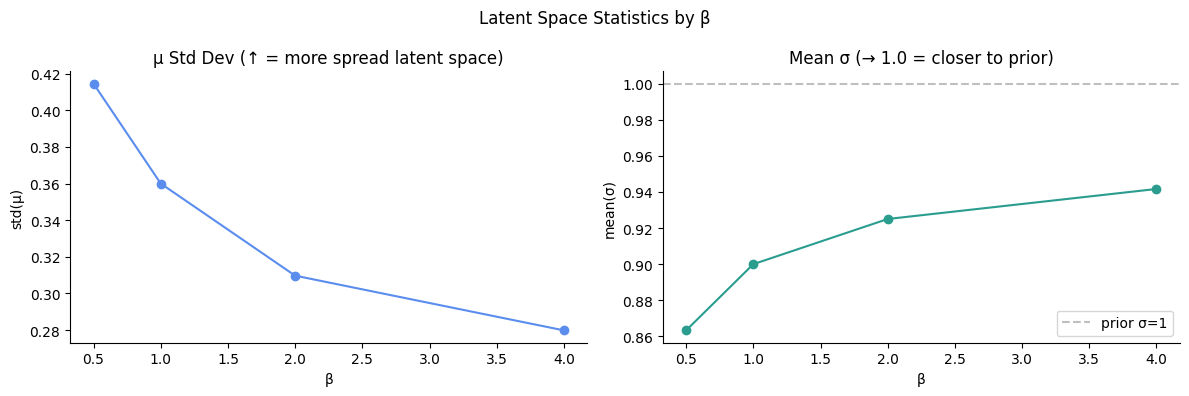

     β       μ std      σ mean
--------------------------------
   0.5      0.4146      0.8633
   1.0      0.3600      0.9000
   2.0      0.3097      0.9250
   4.0      0.2798      0.9416


In [13]:
# β가 클수록 μ가 0에 가까워지고 σ가 1에 가까워짐 — 사전분포에 더 가깝게 압축됨
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

mu_stds, sigma_means, betas_x = [], [], []

for beta, res in results.items():
    model = res['model'].eval()
    mu_list, sig_list = [], []
    with torch.no_grad():
        for x in val_loader:
            mu, lv = model.encoder(x.to(DEVICE))
            mu_list.append(mu.cpu())
            sig_list.append(torch.exp(0.5 * lv).cpu())
    mu_all  = torch.cat(mu_list)
    sig_all = torch.cat(sig_list)
    mu_stds.append(mu_all.std().item())
    sigma_means.append(sig_all.mean().item())
    betas_x.append(beta)

axes[0].plot(betas_x, mu_stds,    'o-', color='#5b8dee')
axes[0].set_title('μ Std Dev (↑ = more spread latent space)')
axes[0].set_xlabel('β'); axes[0].set_ylabel('std(μ)')

axes[1].plot(betas_x, sigma_means, 'o-', color='#2a9d8f')
axes[1].axhline(1.0, color='gray', linestyle='--', alpha=0.5, label='prior σ=1')
axes[1].set_title('Mean σ (→ 1.0 = closer to prior)')
axes[1].set_xlabel('β'); axes[1].set_ylabel('mean(σ)'); axes[1].legend()

for ax in axes:
    for spine in ['top', 'right']: ax.spines[spine].set_visible(False)
plt.suptitle('Latent Space Statistics by β', fontsize=12)
plt.tight_layout()
plt.show()

print(f"{'β':>6}  {'μ std':>10}  {'σ mean':>10}")
print('-' * 32)
for b, ms, sm in zip(betas_x, mu_stds, sigma_means):
    print(f'{b:>6.1f}  {ms:>10.4f}  {sm:>10.4f}')

## 10. 최적 β 선택 & 저장

In [17]:
# 원하는 β 값을 아래에 지정
BEST_BETA = 1.0

best_model = results[BEST_BETA]['model']
save_dir   = CFG['save_dir']

torch.save(best_model.state_dict(), save_dir / 'best.pt')

cfg_out = {k: str(v) if isinstance(v, Path) else v
           for k, v in CFG.items() if k not in {'num_workers', 'processed_root'}}
cfg_out['beta'] = BEST_BETA
with open(save_dir / 'config.json', 'w') as f:
    json.dump(cfg_out, f, indent=2, default=str)

print(f'β={BEST_BETA} 모델 저장 완료 → {save_dir}')

β=1.0 모델 저장 완료 → checkpoints_beta
